# Width-Scaling SGD Experiments

Train parity networks at widths `N = 256, 512, 1024, 2048` with SGD, save train/test curves, and analyze the final checkpoints with PCA rank reduction and weight-variance scaling.


## Setup

Mount Google Drive, clone the public repo, install it in editable mode, and define the run/plot directories.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
from pathlib import Path

GITHUB_REPO_URL = "https://github.com/labofdoubt/feature-learning-parity-task.git"
REPO_DIR = Path("/content/feature-learning-parity-task")

# DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_unfrozen_emb_mup")
# DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_mup")
DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_clamp_smaller_output")

RUNS_DIR = DRIVE_ROOT / "runs"
PLOTS_DIR = DRIVE_ROOT / "plots"
ANALYSIS_DIR = DRIVE_ROOT / "analysis"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
!rm -rf "$REPO_DIR"
!git clone "$GITHUB_REPO_URL" "$REPO_DIR"
%cd "$REPO_DIR"
!pip install -e .

Cloning into '/content/feature-learning-parity-task'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 119 (delta 68), reused 98 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 1.65 MiB | 7.77 MiB/s, done.
Resolving deltas: 100% (68/68), done.
/content/feature-learning-parity-task
Obtaining file:///content/feature-learning-parity-task
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for parity-net (pyproject.toml) ... done
  Created wheel for parity-net: filename=parity_net-0.1.0-0.editable-py3-none-any.whl size=3070 sha256=ae443889a66faf3e11c60154907e4358e73baec1677bbd2a14ea61b3efb274bb
  Stored in directory: /tmp/pip-ephem-wheel-cache-6_ol15uk/wheels/a2/05/6b/5da726f55833c1e289bd27eaf

## Train Width Sweep

This cell writes one config per width and runs training inside the notebook kernel so the progress bar renders in Colab. Existing final checkpoints are skipped unless `FORCE_RETRAIN = True`.


In [27]:
from pathlib import Path

import yaml

from parity_net.config import load_config
from parity_net.train import train

WIDTHS = [256, 512, 1024, 2048, 4096]
FORCE_RETRAIN = False


def make_config(N: int, output_dir: Path) -> dict:
    return {
        "model": {
            "input_dim": 32,
            "relevant_dim": 16,
            "N": N,
            "L": 2,
            "activation": "half-tanh",
            "use_readout_barrier": False,
            "embedding_weight_variance": 1.0 / 32,
            "freeze_embedding": True,
            "hidden_weight_variance": 1.0 / N,
            "readout_weight_variance": 1 / N**2,
            "use_post_activation_linear": False,
            "bias": False,
        },
        "training": {
            "num_steps": 100_000,
            "test_samples": 100_000,
            "batch_size": 512,
            "seed": 0,
            "device": "cuda",
            "dtype": "float32",
            "log_every": 1_000,
            "checkpoint_every": 1_000,
            "output_dir": str(output_dir),
            "barrier_c": 7.0/N,
            "barrier_lambda": 10.0,
            "optimizer": {
                "name": "sgd",
                "lr": 1e-2,
                "lr_embedding": None,
                "lr_hidden": None,
                "lr_readout": None,
                "weight_decay": 0.0,
                "momentum": 0.9,
                "betas": [0.9, 0.999],
            },
        },
    }


def make_config_mup(N: int, output_dir: Path) -> dict:
    config = make_config(N, output_dir)
    base_lr = config["training"]["optimizer"]["lr"]
    config["model"]["readout_weight_variance"] = 256 / N**2
    config["training"]["optimizer"]["lr_embedding"] = base_lr * N / 256
    config["training"]["optimizer"]["lr_hidden"] = base_lr
    config["training"]["optimizer"]["lr_readout"] = base_lr * 256 / N
    return config


CONFIG_FACTORY = make_config  # Change to make_config_mup for the muP-scaled sweep.


In [28]:
config_paths = {}
for N in WIDTHS:
    run_dir = RUNS_DIR / f"N_{N}"
    run_dir.mkdir(parents=True, exist_ok=True)
    config_path = run_dir / "config.yaml"
    final_checkpoint = run_dir / "checkpoints" / "final.pt"

    if final_checkpoint.exists() and not FORCE_RETRAIN:
        config_paths[N] = config_path
        print(
            f"N={N}: final checkpoint exists, skipping training: {final_checkpoint}. "
            "Set FORCE_RETRAIN=True or choose a new DRIVE_ROOT to train with changed config values."
        )
        continue

    config = CONFIG_FACTORY(N, run_dir)
    with config_path.open("w") as f:
        yaml.safe_dump(config, f, sort_keys=False)
    config_paths[N] = config_path

    print(f"N={N}: training with {config_path}")
    final_path = train(load_config(config_path))
    print(f"N={N}: saved final checkpoint to {final_path}")


N=256: training with /content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_clamp_smaller_output/runs/N_256/config.yaml


training:   0%|          | 0/100000 [00:00<?, ?step/s]

{'step': 1000, 'elapsed_seconds': 3.6861831650003296, 'train_mse': 0.4502866268157959, 'barrier': 0.0, 'loss': 0.4502866268157959, 'test_mse': 0.44902536273002625, 'test_mse_d2': 0.035800568759441376, 'test_mse_d4': 0.8580945134162903, 'test_mse_d8': 1.004880428314209, 'test_mse_d16': 1.0068367719650269}
{'step': 2000, 'elapsed_seconds': 7.459760394000114, 'train_mse': 0.22404548525810242, 'barrier': 0.0, 'loss': 0.22404548525810242, 'test_mse': 0.22263137996196747, 'test_mse_d2': 0.015709999948740005, 'test_mse_d4': 0.05113033205270767, 'test_mse_d8': 1.0033819675445557, 'test_mse_d16': 1.0025051832199097}
{'step': 3000, 'elapsed_seconds': 11.20036934000018, 'train_mse': 0.20982861518859863, 'barrier': 0.0, 'loss': 0.20982861518859863, 'test_mse': 0.21024242043495178, 'test_mse_d2': 0.009388577193021774, 'test_mse_d4': 0.01717996597290039, 'test_mse_d8': 1.0028982162475586, 'test_mse_d16': 1.0040113925933838}
{'step': 4000, 'elapsed_seconds': 14.908694675999868, 'train_mse': 0.2048495

training:   0%|          | 0/100000 [00:00<?, ?step/s]

{'step': 1000, 'elapsed_seconds': 3.6890072189999046, 'train_mse': 0.2508508265018463, 'barrier': 0.0, 'loss': 0.2508508265018463, 'test_mse': 0.2511453628540039, 'test_mse_d2': 0.022014157846570015, 'test_mse_d4': 0.1383175402879715, 'test_mse_d8': 1.0121028423309326, 'test_mse_d16': 1.0135915279388428}
{'step': 2000, 'elapsed_seconds': 7.544630099000642, 'train_mse': 0.20867468416690826, 'barrier': 0.0, 'loss': 0.20867468416690826, 'test_mse': 0.20912332832813263, 'test_mse_d2': 0.008699615485966206, 'test_mse_d4': 0.011654791422188282, 'test_mse_d8': 1.0084779262542725, 'test_mse_d16': 1.0036779642105103}
{'step': 3000, 'elapsed_seconds': 11.33435602999998, 'train_mse': 0.20695175230503082, 'barrier': 0.0, 'loss': 0.20695175230503082, 'test_mse': 0.2057703733444214, 'test_mse_d2': 0.005088713485747576, 'test_mse_d4': 0.007148079574108124, 'test_mse_d8': 1.0037410259246826, 'test_mse_d16': 1.0097713470458984}
{'step': 4000, 'elapsed_seconds': 15.076479610000206, 'train_mse': 0.183272

...

{'step': 1000, 'elapsed_seconds': 3.744706411000152, 'train_mse': 0.2161397933959961, 'barrier': 0.0, 'loss': 0.2161397933959961, 'test_mse': 0.21587741374969482, 'test_mse_d2': 0.01292124018073082, 'test_mse_d4': 0.018753744661808014, 'test_mse_d8': 1.0208333730697632, 'test_mse_d16': 1.0181097984313965}
{'step': 2000, 'elapsed_seconds': 7.547410744999979, 'train_mse': 0.19598615169525146, 'barrier': 0.0, 'loss': 0.19598615169525146, 'test_mse': 0.19662074744701385, 'test_mse_d2': 0.006050495430827141, 'test_mse_d4': 0.00631027203053236, 'test_mse_d8': 0.9320423007011414, 'test_mse_d16': 1.0115816593170166}
{'step': 3000, 'elapsed_seconds': 11.348114415000055, 'train_mse': 0.15267415344715118, 'barrier': 0.0, 'loss': 0.15267415344715118, 'test_mse': 0.15304197371006012, 'test_mse_d2': 0.003822364378720522, 'test_mse_d4': 0.005014167167246342, 'test_mse_d8': 0.610940158367157, 'test_mse_d16': 1.02311372756958}
{'step': 4000, 'elapsed_seconds': 15.16538146899984, 'train_mse': 0.12336868

training:   0%|          | 0/100000 [00:00<?, ?step/s]

{'step': 1000, 'elapsed_seconds': 5.50252432599973, 'train_mse': 0.2183733433485031, 'barrier': 0.0, 'loss': 0.2183733433485031, 'test_mse': 0.21652261912822723, 'test_mse_d2': 0.010019063018262386, 'test_mse_d4': 0.008285388350486755, 'test_mse_d8': 1.039698839187622, 'test_mse_d16': 1.0551477670669556}
{'step': 2000, 'elapsed_seconds': 11.26537287500014, 'train_mse': 0.19522756338119507, 'barrier': 0.0, 'loss': 0.19522756338119507, 'test_mse': 0.1933785378932953, 'test_mse_d2': 0.005381615366786718, 'test_mse_d4': 0.003928216639906168, 'test_mse_d8': 0.9026924967765808, 'test_mse_d16': 1.036527156829834}
{'step': 3000, 'elapsed_seconds': 17.108459517000483, 'train_mse': 0.11362281441688538, 'barrier': 0.0, 'loss': 0.11362281441688538, 'test_mse': 0.11393506079912186, 'test_mse_d2': 0.004022921901196241, 'test_mse_d4': 0.004045551642775536, 'test_mse_d8': 0.31426265835762024, 'test_mse_d16': 1.0321351289749146}
{'step': 4000, 'elapsed_seconds': 22.909302703999856, 'train_mse': 0.07661

training:   0%|          | 0/100000 [00:00<?, ?step/s]

{'step': 1000, 'elapsed_seconds': 16.000208345999454, 'train_mse': 0.20682911574840546, 'barrier': 0.0, 'loss': 0.20682911574840546, 'test_mse': 0.2010522484779358, 'test_mse_d2': 0.008035888895392418, 'test_mse_d4': 0.005172171629965305, 'test_mse_d8': 0.9072668552398682, 'test_mse_d16': 1.1162742376327515}
{'step': 2000, 'elapsed_seconds': 33.64498305199959, 'train_mse': 0.09381554275751114, 'barrier': 0.0, 'loss': 0.09381554275751114, 'test_mse': 0.09317521005868912, 'test_mse_d2': 0.004933193325996399, 'test_mse_d4': 0.0033387530129402876, 'test_mse_d8': 0.12421132624149323, 'test_mse_d16': 1.0963847637176514}
{'step': 3000, 'elapsed_seconds': 51.26684991299953, 'train_mse': 0.07802321016788483, 'barrier': 0.0, 'loss': 0.07802321016788483, 'test_mse': 0.07791773974895477, 'test_mse_d2': 0.0031824028119444847, 'test_mse_d4': 0.002118218457326293, 'test_mse_d8': 0.019227460026741028, 'test_mse_d16': 1.0963791608810425}
{'step': 4000, 'elapsed_seconds': 68.9512781859994, 'train_mse': 

## Train/Test Curves

Read `metrics.csv` from each run, save one plot per width, and save combined train/test plots across widths.


In [5]:
# DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_unfrozen_emb")
# DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd")
DRIVE_ROOT = Path("/content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_clamp_smaller_output")

RUNS_DIR = DRIVE_ROOT / "runs"
PLOTS_DIR = DRIVE_ROOT / "plots"
ANALYSIS_DIR = DRIVE_ROOT / "analysis"

WIDTHS = [256, 512, 1024, 2048, 4096]

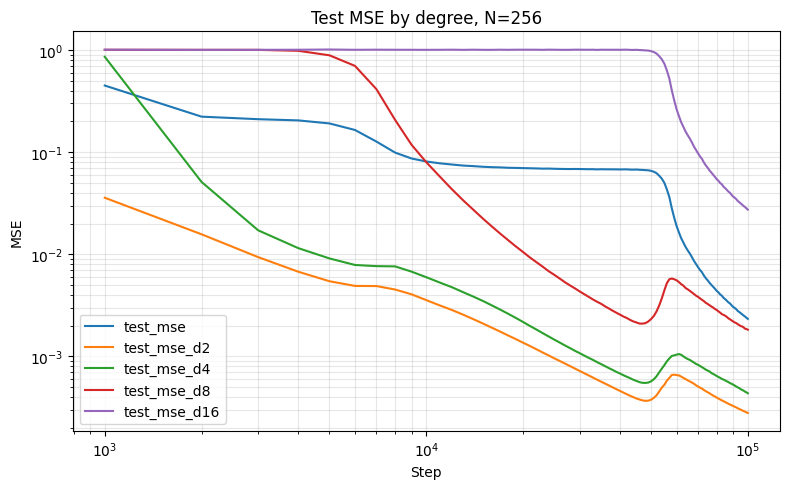

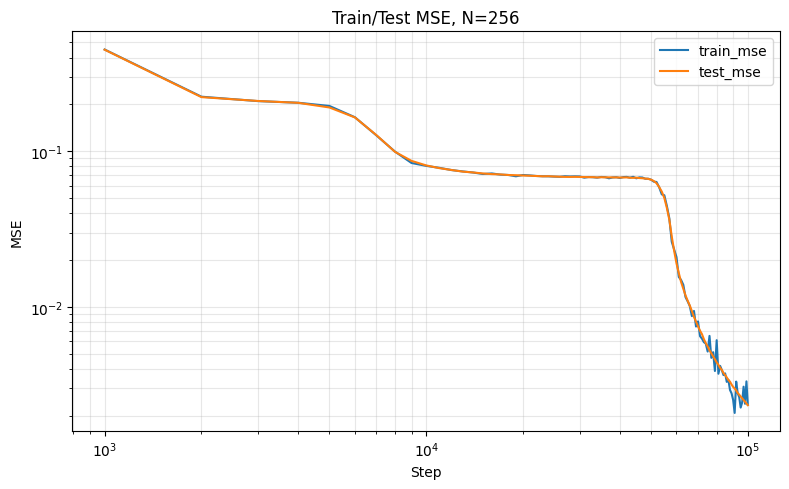

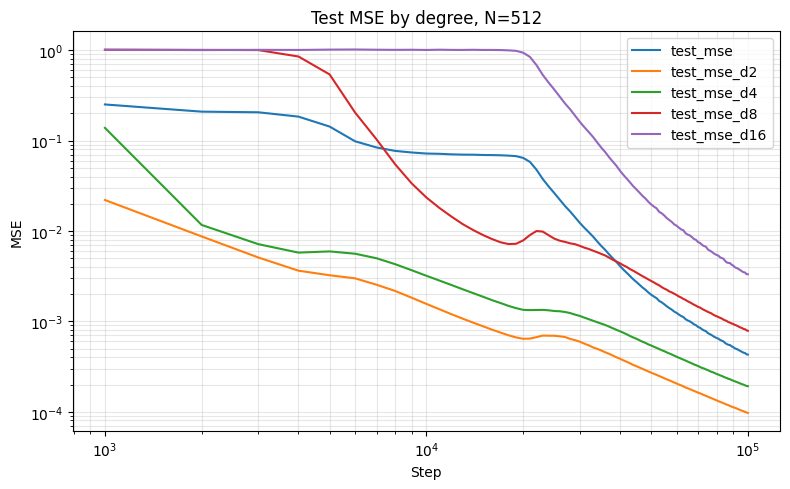

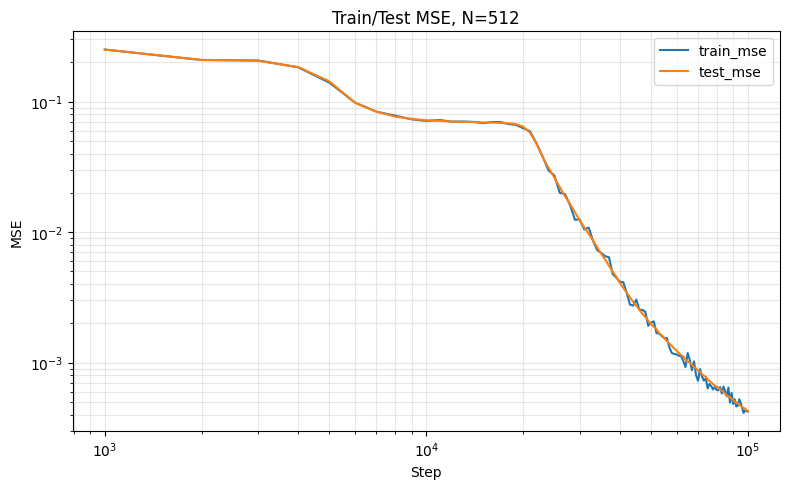

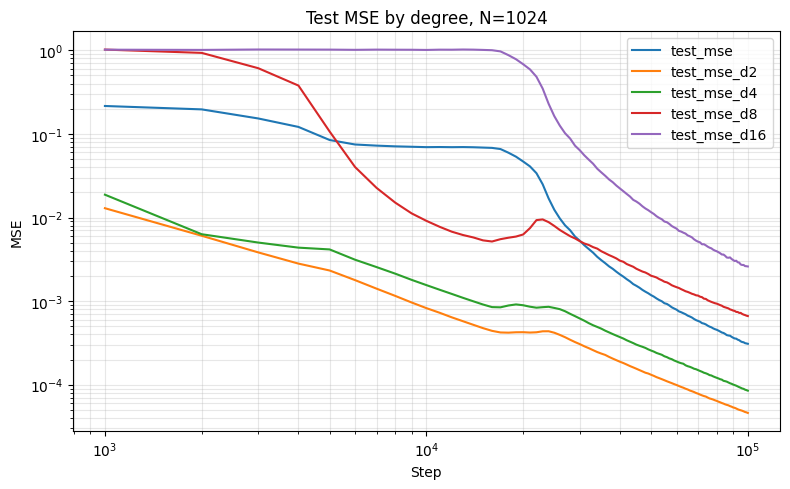

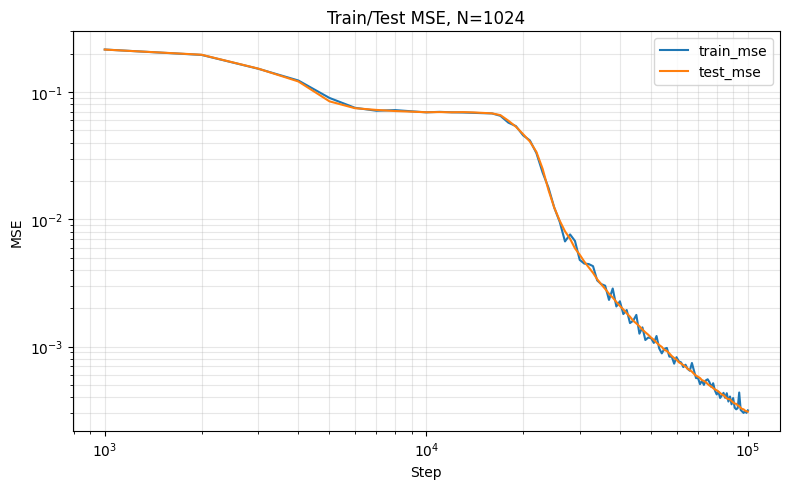

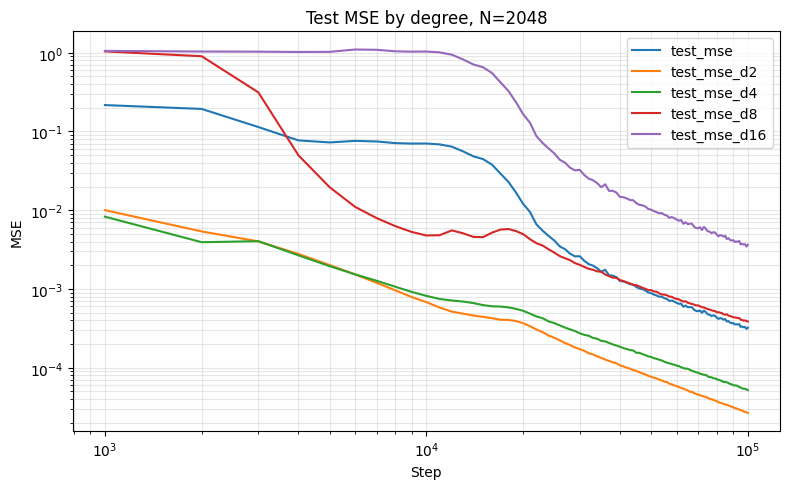

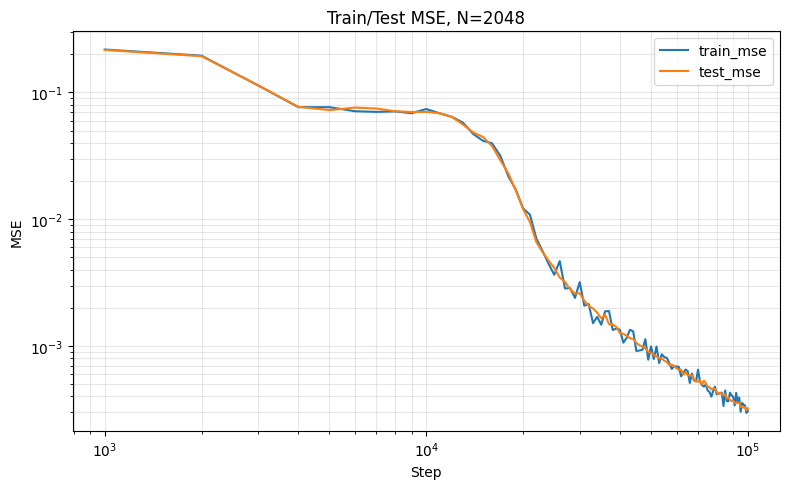

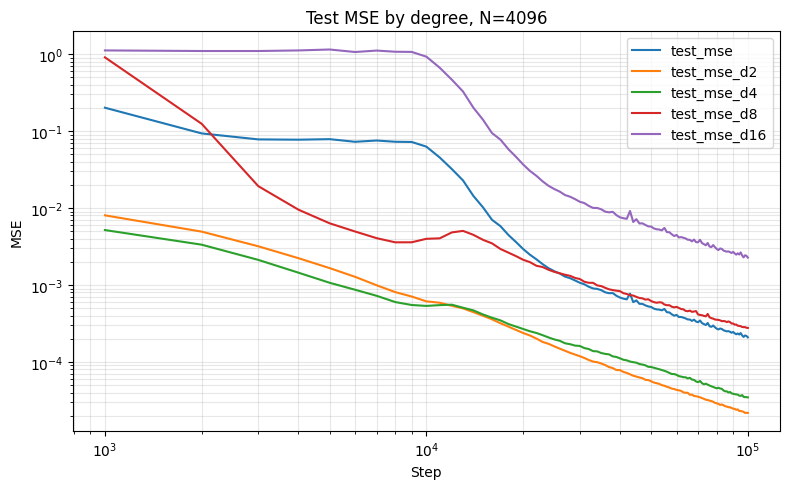

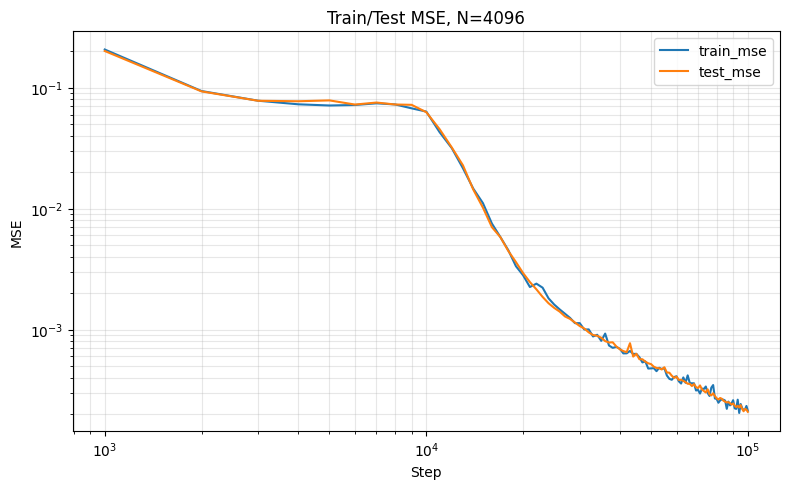

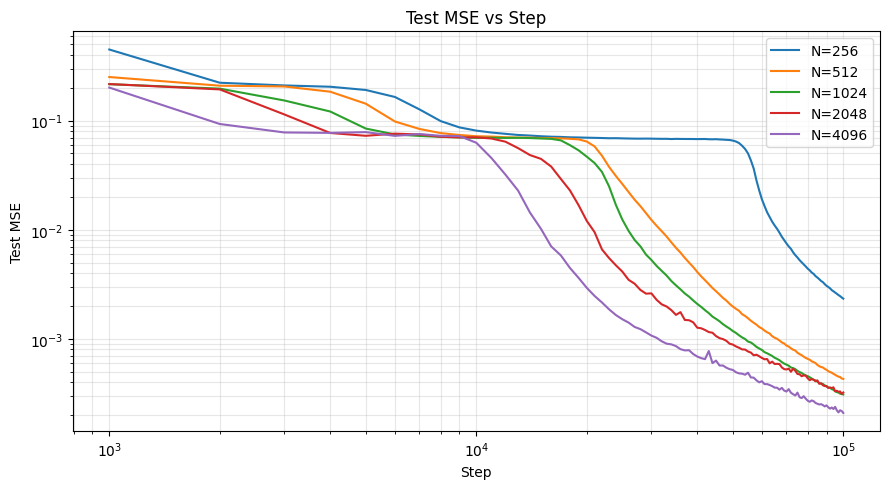

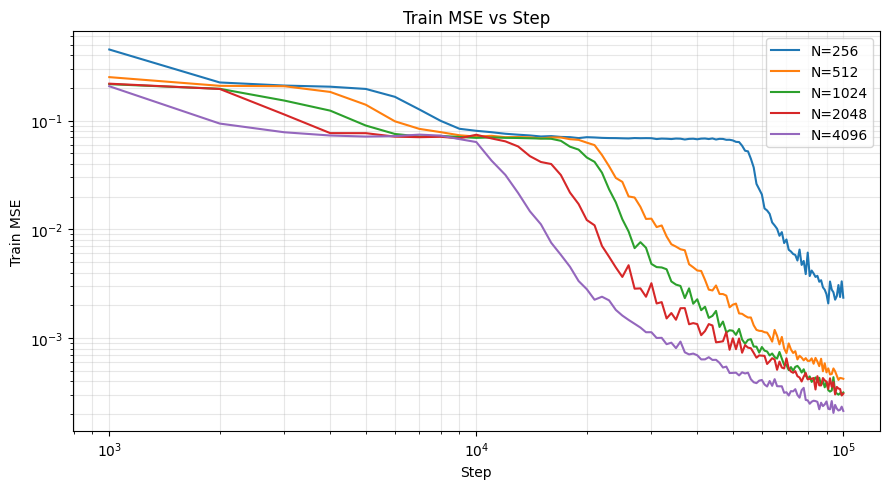

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

USE_LOG_MSE_AXIS = True
USE_LOG_STEP_AXIS = True
TEST_MSE_COLUMNS = ["test_mse", "test_mse_d2", "test_mse_d4", "test_mse_d8", "test_mse_d16"]


def axis_has_positive_data(ax, axis):
    for line in ax.lines:
        values = line.get_xdata() if axis == "x" else line.get_ydata()
        if len(values) and pd.Series(values).dropna().gt(0).any():
            return True
    return False


def maybe_log_y(ax):
    if USE_LOG_MSE_AXIS and axis_has_positive_data(ax, "y"):
        ax.set_yscale("log")


def maybe_log_x(ax):
    if USE_LOG_STEP_AXIS and axis_has_positive_data(ax, "x"):
        ax.set_xscale("log")


metrics_by_width = {}
for N in WIDTHS:
    metrics_path = RUNS_DIR / f"N_{N}" / "metrics.csv"
    if not metrics_path.exists():
        print(f"N={N}: missing {metrics_path}")
        continue
    df = pd.read_csv(metrics_path)
    metrics_by_width[N] = df

    fig, ax = plt.subplots(figsize=(8, 5))
    for column in TEST_MSE_COLUMNS:
        if column in df.columns:
            ax.plot(df["step"], df[column], label=column)
    ax.set_xlabel("Step")
    ax.set_ylabel("MSE")
    ax.set_title(f"Test MSE by degree, N={N}")
    maybe_log_x(ax)
    maybe_log_y(ax)
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"test_mse_by_degree_N_{N}.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["step"], df["train_mse"], label="train_mse")
    ax.plot(df["step"], df["test_mse"], label="test_mse")
    ax.set_xlabel("Step")
    ax.set_ylabel("MSE")
    ax.set_title(f"Train/Test MSE, N={N}")
    maybe_log_x(ax)
    maybe_log_y(ax)
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"train_test_mse_N_{N}.png", dpi=150)
    plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for N, df in metrics_by_width.items():
    ax.plot(df["step"], df["test_mse"], label=f"N={N}")
ax.set_xlabel("Step")
ax.set_ylabel("Test MSE")
ax.set_title("Test MSE vs Step")
maybe_log_x(ax)
maybe_log_y(ax)
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "test_mse_by_width.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for N, df in metrics_by_width.items():
    ax.plot(df["step"], df["train_mse"], label=f"N={N}")
ax.set_xlabel("Step")
ax.set_ylabel("Train MSE")
ax.set_title("Train MSE vs Step")
maybe_log_x(ax)
maybe_log_y(ax)
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "train_mse_by_width.png", dpi=150)
plt.show()


## Final-Checkpoint PCA and Weight-Variance Analysis

For each final checkpoint, load the saved test set, compute PCA ranks at the selected residual-stream layer, sweep PCA interventions, and collect trained weight variances.


N=256: collecting activations from 20000 saved test samples


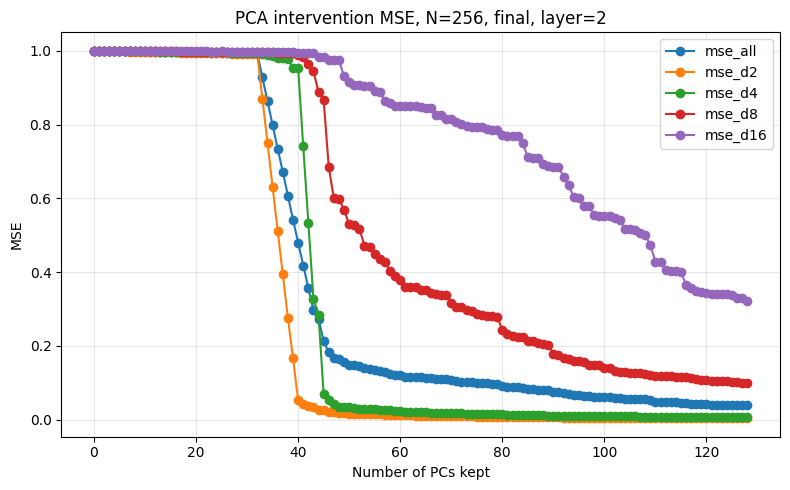

N=512: collecting activations from 20000 saved test samples


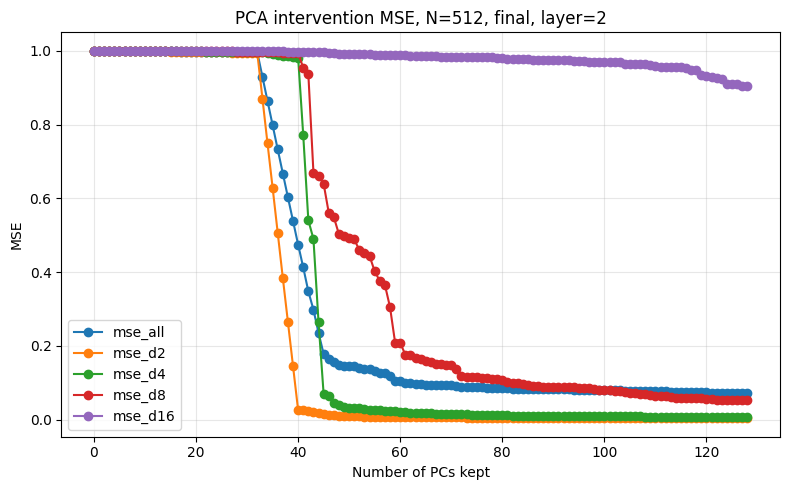

N=1024: collecting activations from 20000 saved test samples


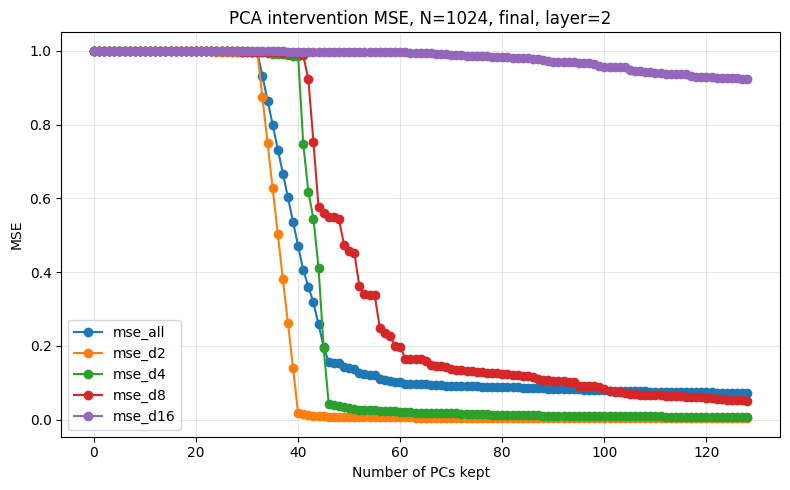

N=2048: collecting activations from 20000 saved test samples


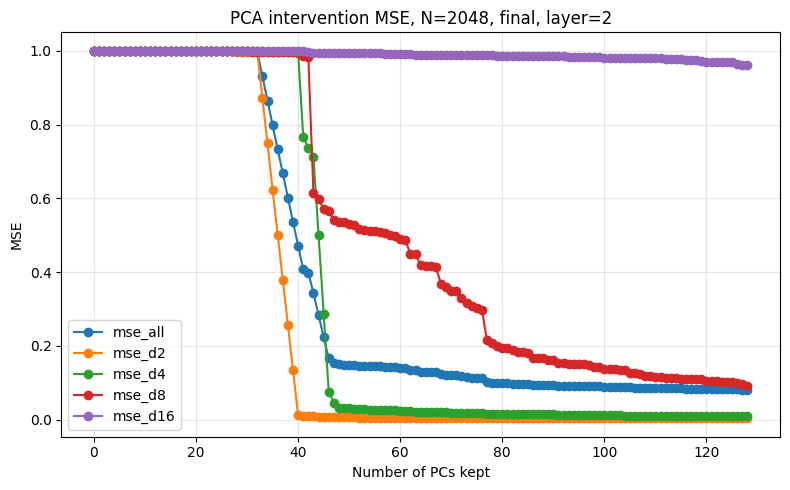

N=4096: collecting activations from 20000 saved test samples


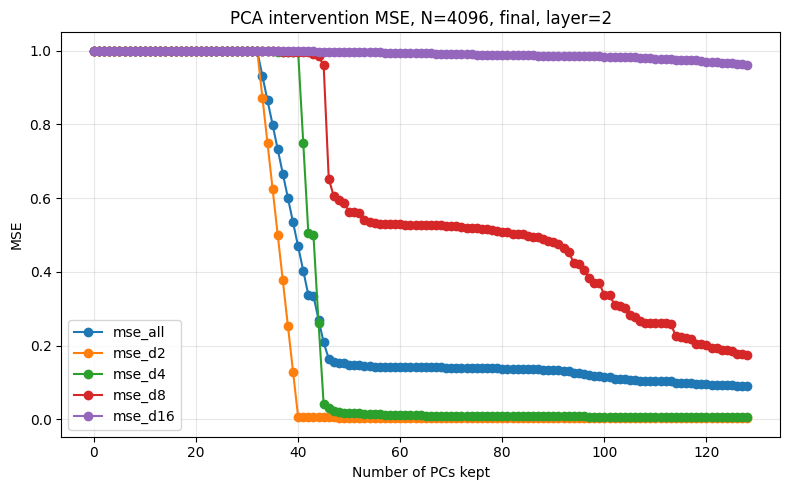

,N,checkpoint,layer_idx,rank_90,rank_99,num_dimensions
0,256,final,0,29,32,256
1,256,final,1,29,53,256
2,256,final,2,30,79,256
3,512,final,0,29,32,512
4,512,final,1,29,57,512
5,512,final,2,30,138,512
6,1024,final,0,29,32,1024
7,1024,final,1,29,75,1024
8,1024,final,2,30,278,1024
9,2048,final,0,29,32,2048


,N,checkpoint,layer,variance
0,256,final,embedding.weight,0.031249
1,256,final,blocks.0.linear.weight,0.004335
2,256,final,blocks.1.linear.weight,0.004602
3,256,final,readout.weight,0.025210
4,512,final,embedding.weight,0.031249
5,512,final,blocks.0.linear.weight,0.002013
6,512,final,blocks.1.linear.weight,0.002086
7,512,final,readout.weight,0.009828
8,1024,final,embedding.weight,0.031249
9,1024,final,blocks.0.linear.weight,0.000986


In [7]:
import torch

from parity_net.analysis import (
    collect_layer_activations,
    make_pca_intervention,
    pca_from_activations,
    per_degree_mse,
    predict_in_batches,
    rank_for_threshold,
)
from parity_net.checkpoint import load_checkpoint
from parity_net.data import ParityDataset, load_dataset
from parity_net.train import resolve_device, resolve_dtype

PCA_SAMPLES = 20_000
CHECKPOINT_STEP = "final"  # Use "final" or an integer step, e.g. 50000.
USE_LOG_PCA_MSE_AXIS = False
ANALYSIS_LAYER_IDX = 2  # 0 is embedding, later indices are after residual blocks.
KEEP_PCS_MIN = 0
KEEP_PCS_MAX = 128
KEEP_PCS_STEP = 1


def checkpoint_name(checkpoint_step):
    if checkpoint_step == "final":
        return "final.pt", "final"
    if isinstance(checkpoint_step, int):
        return f"step_{checkpoint_step:08d}.pt", f"step_{checkpoint_step:08d}"
    raise ValueError('CHECKPOINT_STEP must be "final" or an integer step')


def assert_finite_tensor(tensor, label):
    if not torch.isfinite(tensor).all().item():
        raise ValueError(f"{label} contains NaN or Inf")


def assert_finite_metrics(metrics, label):
    bad = {key: value for key, value in metrics.items() if not pd.notna(value)}
    if bad:
        raise ValueError(f"{label} contains non-finite values: {bad}")


checkpoint_file, checkpoint_label = checkpoint_name(CHECKPOINT_STEP)
rank_rows = []
weight_rows = []
pca_sweep_by_width = {}
skipped_widths = []

for N in WIDTHS:
    run_dir = RUNS_DIR / f"N_{N}"
    checkpoint_path = run_dir / "checkpoints" / checkpoint_file
    if not checkpoint_path.exists():
        print(f"N={N}: missing checkpoint {checkpoint_path}, skipping analysis")
        skipped_widths.append({"N": N, "reason": "missing checkpoint"})
        continue

    try:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model, payload, _ = load_checkpoint(checkpoint_path, device)
        training = payload["config"]["training"]
        model_config = payload["config"]["model"]
        device = resolve_device(training["device"])
        dtype = resolve_dtype(training["dtype"])
        model = model.to(device=device, dtype=dtype)
        batch_size = training["batch_size"]

        test_data_path = Path(payload.get("test_data_path") or run_dir / "test_data.pt")
        test_data = load_dataset(test_data_path, device, dtype)
        if PCA_SAMPLES < test_data.x.shape[0]:
            heldout = ParityDataset(x=test_data.x[:PCA_SAMPLES], y=test_data.y[:PCA_SAMPLES])
        else:
            heldout = test_data

        local_weight_rows = []
        for layer, variance in model.weight_variances().items():
            if not pd.notna(variance):
                raise ValueError(f"weight variance for {layer} is non-finite: {variance}")
            local_weight_rows.append({"N": N, "checkpoint": checkpoint_label, "layer": layer, "variance": variance})

        print(f"N={N}: collecting activations from {heldout.x.shape[0]} saved test samples")
        activations = collect_layer_activations(model, heldout.x, batch_size)
        for layer_idx, layer_acts in enumerate(activations):
            assert_finite_tensor(layer_acts, f"N={N} activations layer {layer_idx}")

        pcas = [pca_from_activations(layer_acts) for layer_acts in activations]
        for layer_idx, pca in enumerate(pcas):
            assert_finite_tensor(pca["cumulative_explained_variance"], f"N={N} PCA cumulative layer {layer_idx}")
            assert_finite_tensor(pca["components"], f"N={N} PCA components layer {layer_idx}")

        local_rank_rows = []
        for layer_idx, pca in enumerate(pcas):
            cumulative = pca["cumulative_explained_variance"]
            local_rank_rows.append(
                {
                    "N": N,
                    "checkpoint": checkpoint_label,
                    "layer_idx": layer_idx,
                    "rank_90": rank_for_threshold(cumulative, 0.90),
                    "rank_99": rank_for_threshold(cumulative, 0.99),
                    "num_dimensions": cumulative.numel(),
                }
            )

        if ANALYSIS_LAYER_IDX < 0 or ANALYSIS_LAYER_IDX >= len(pcas):
            raise ValueError(f"ANALYSIS_LAYER_IDX must be in [0, {len(pcas) - 1}]")

        max_available_pcs = pcas[ANALYSIS_LAYER_IDX]["components"].shape[0]
        keep_pcs_max_effective = min(KEEP_PCS_MAX, max_available_pcs)
        keep_pcs_values = list(range(KEEP_PCS_MIN, keep_pcs_max_effective + 1, KEEP_PCS_STEP))
        if keep_pcs_values[-1] != keep_pcs_max_effective:
            keep_pcs_values.append(keep_pcs_max_effective)

        sweep_rows = []
        for keep_pcs in keep_pcs_values:
            intervention = make_pca_intervention(pcas[ANALYSIS_LAYER_IDX], keep_pcs)
            with torch.no_grad():
                pred_intervened = predict_in_batches(
                    model,
                    heldout.x,
                    batch_size,
                    intervention=(ANALYSIS_LAYER_IDX, intervention),
                )
            assert_finite_tensor(pred_intervened, f"N={N} intervened predictions keep_pcs={keep_pcs}")
            metrics = per_degree_mse(pred_intervened, heldout.y)
            assert_finite_metrics(metrics, f"N={N} MSE metrics keep_pcs={keep_pcs}")
            sweep_rows.append(
                {
                    "N": N,
                    "checkpoint": checkpoint_label,
                    "intervention_layer": ANALYSIS_LAYER_IDX,
                    "keep_pcs": keep_pcs,
                    **metrics,
                }
            )

        sweep_df = pd.DataFrame(sweep_rows)
        pca_sweep_by_width[N] = sweep_df
        sweep_df.to_csv(ANALYSIS_DIR / f"pca_mse_sweep_{checkpoint_label}_N_{N}.csv", index=False)

        fig, ax = plt.subplots(figsize=(8, 5))
        sweep_df.plot(
            x="keep_pcs",
            y=["mse_all", "mse_d2", "mse_d4", "mse_d8", "mse_d16"],
            marker="o",
            ax=ax,
        )
        ax.set_xlabel("Number of PCs kept")
        ax.set_ylabel("MSE")
        ax.set_title(f"PCA intervention MSE, N={N}, {checkpoint_label}, layer={ANALYSIS_LAYER_IDX}")
        if USE_LOG_PCA_MSE_AXIS:
            ax.set_yscale("log")
        ax.grid(True, alpha=0.3, which="both")
        fig.tight_layout()
        fig.savefig(PLOTS_DIR / f"pca_mse_sweep_{checkpoint_label}_layer_{ANALYSIS_LAYER_IDX}_N_{N}.png", dpi=150)
        plt.show()

        weight_rows.extend(local_weight_rows)
        rank_rows.extend(local_rank_rows)

    except Exception as exc:
        print(f"N={N}: checkpoint {checkpoint_path} is broken or non-finite, skipping. Reason: {exc}")
        skipped_widths.append({"N": N, "reason": str(exc)})
        plt.close("all")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        continue

rank_df = pd.DataFrame(rank_rows)
weight_variance_df = pd.DataFrame(weight_rows)
skipped_widths_df = pd.DataFrame(skipped_widths)
rank_df.to_csv(ANALYSIS_DIR / f"pca_ranks_by_width_{checkpoint_label}.csv", index=False)
weight_variance_df.to_csv(ANALYSIS_DIR / f"weight_variances_by_width_{checkpoint_label}.csv", index=False)
skipped_widths_df.to_csv(ANALYSIS_DIR / f"skipped_widths_{checkpoint_label}.csv", index=False)

display(rank_df)
display(weight_variance_df)
if not skipped_widths_df.empty:
    print("Skipped widths")
    display(skipped_widths_df)


## Summary Plots

Plot effective residual-stream dimension versus width, PCA intervention curves across widths, and trained weight variance scaling versus width.


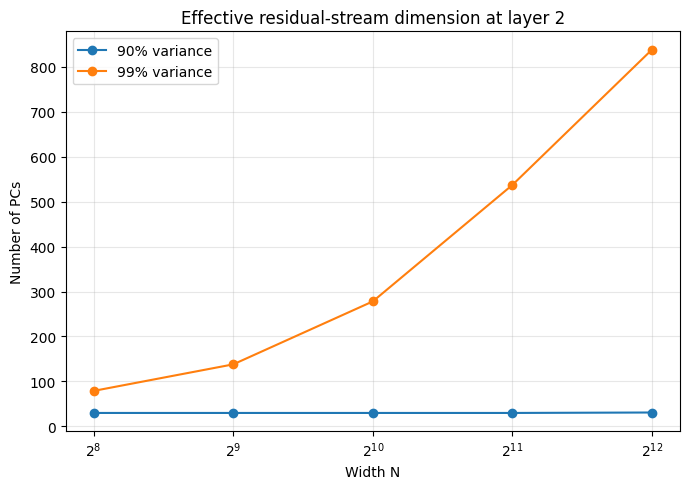

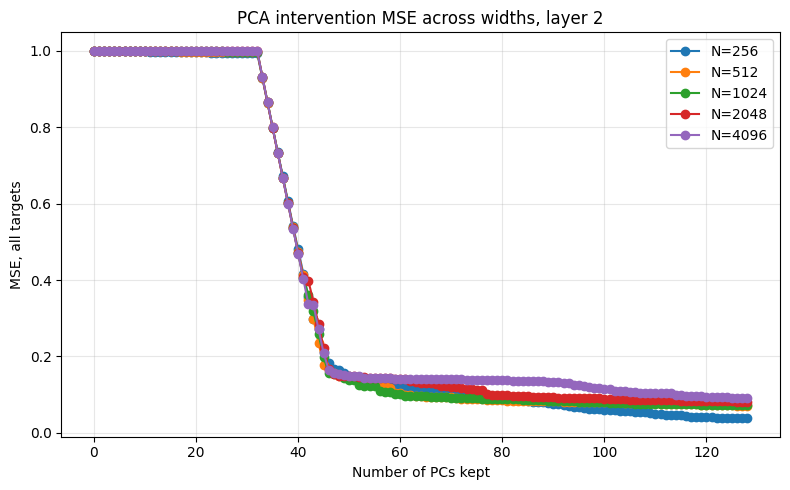

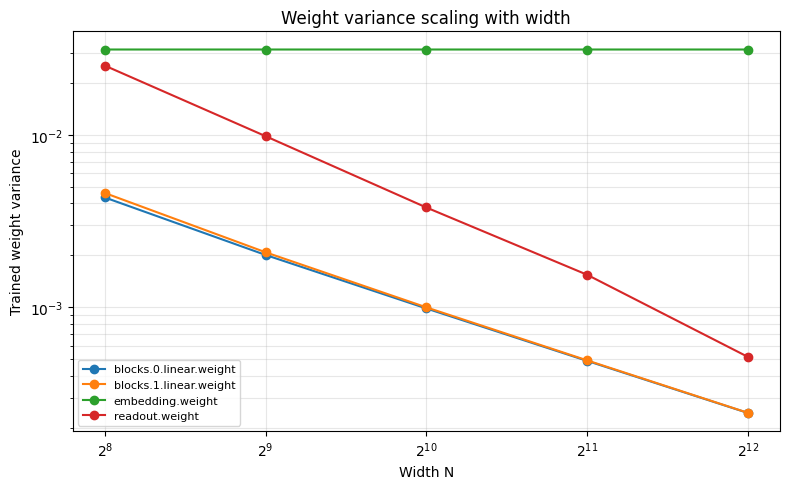

In [8]:
layer_rank_df = rank_df[rank_df["layer_idx"] == ANALYSIS_LAYER_IDX].copy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(layer_rank_df["N"], layer_rank_df["rank_90"], marker="o", label="90% variance")
ax.plot(layer_rank_df["N"], layer_rank_df["rank_99"], marker="o", label="99% variance")
ax.set_xscale("log", base=2)
ax.set_xlabel("Width N")
ax.set_ylabel("Number of PCs")
ax.set_title(f"Effective residual-stream dimension at layer {ANALYSIS_LAYER_IDX}")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"effective_dimension_vs_width_layer_{ANALYSIS_LAYER_IDX}.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for N, sweep_df in pca_sweep_by_width.items():
    ax.plot(sweep_df["keep_pcs"], sweep_df["mse_all"], marker="o", label=f"N={N}")
ax.set_xlabel("Number of PCs kept")
ax.set_ylabel("MSE, all targets")
ax.set_title(f"PCA intervention MSE across widths, layer {ANALYSIS_LAYER_IDX}")
if USE_LOG_PCA_MSE_AXIS:
    ax.set_yscale("log")
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"pca_mse_all_sweep_by_width_layer_{ANALYSIS_LAYER_IDX}.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for layer, group in weight_variance_df.groupby("layer"):
    group = group.sort_values("N")
    ax.plot(group["N"], group["variance"], marker="o", label=layer)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Width N")
ax.set_ylabel("Trained weight variance")
ax.set_title("Weight variance scaling with width")
ax.grid(True, alpha=0.3, which="both")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"weight_variance_vs_width_layer_{ANALYSIS_LAYER_IDX}.png", dpi=150)
plt.show()


## Activation Variance vs Width

For one saved test sample, plot the variance across coordinates of each activation vector after the embedding, after each residual block, and after the readout as a function of width.


,N,checkpoint,layer_idx,layer,variance
0,256,step_00001000,0,embedding,0.996729
1,256,step_00001000,1,block_1,1.128146
2,256,step_00001000,2,block_2,1.207542
3,256,step_00001000,3,readout,0.626021
4,512,step_00001000,0,embedding,0.999268
5,512,step_00001000,1,block_1,1.105387
6,512,step_00001000,2,block_2,1.224055
7,512,step_00001000,3,readout,0.684185
8,1024,step_00001000,0,embedding,0.999460
9,1024,step_00001000,1,block_1,1.105622


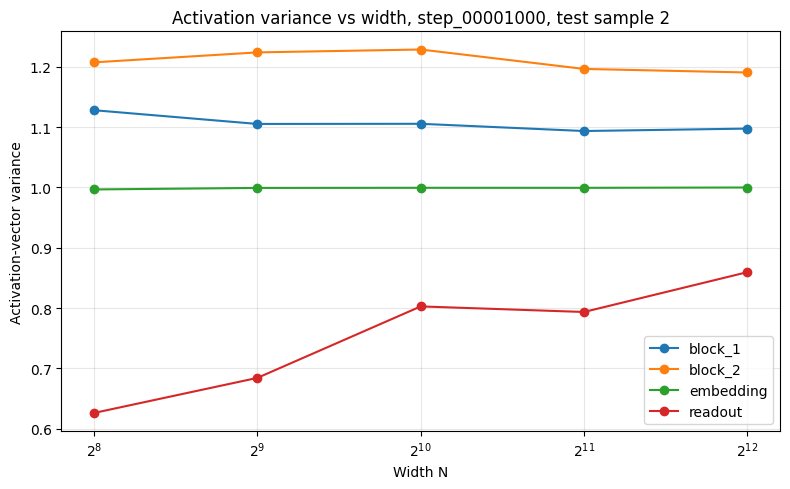

In [9]:
ACTIVATION_SAMPLE_IDX = 2
ACTIVATION_CHECKPOINT_STEP = 1000  # Use "final" or an integer step.

from parity_net.checkpoint import load_checkpoint
from parity_net.data import load_dataset
from parity_net.train import resolve_device, resolve_dtype


def activation_checkpoint_name(checkpoint_step):
    if checkpoint_step == "final":
        return "final.pt", "final"
    if isinstance(checkpoint_step, int):
        return f"step_{checkpoint_step:08d}.pt", f"step_{checkpoint_step:08d}"
    raise ValueError('ACTIVATION_CHECKPOINT_STEP must be "final" or an integer step')


activation_checkpoint_file, activation_checkpoint_label = activation_checkpoint_name(ACTIVATION_CHECKPOINT_STEP)
activation_variance_rows = []
for N in WIDTHS:
    run_dir = RUNS_DIR / f"N_{N}"
    checkpoint_path = run_dir / "checkpoints" / activation_checkpoint_file
    if not checkpoint_path.exists():
        print(f"N={N}: missing checkpoint {checkpoint_path}, skipping activation variance")
        continue

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, payload, _ = load_checkpoint(checkpoint_path, device)
    training = payload["config"]["training"]
    device = resolve_device(training["device"])
    dtype = resolve_dtype(training["dtype"])
    model = model.to(device=device, dtype=dtype)

    test_data_path = Path(payload.get("test_data_path") or run_dir / "test_data.pt")
    test_data = load_dataset(test_data_path, device, dtype)
    if ACTIVATION_SAMPLE_IDX < 0 or ACTIVATION_SAMPLE_IDX >= test_data.x.shape[0]:
        raise ValueError(
            f"ACTIVATION_SAMPLE_IDX={ACTIVATION_SAMPLE_IDX} is outside saved test set "
            f"of size {test_data.x.shape[0]} for N={N}"
        )

    x_sample = test_data.x[ACTIVATION_SAMPLE_IDX : ACTIVATION_SAMPLE_IDX + 1]
    model.eval()
    with torch.no_grad():
        readout, activations = model(x_sample, return_activations=True)

    for layer_idx, h in enumerate(activations):
        layer_name = "embedding" if layer_idx == 0 else f"block_{layer_idx}"
        activation_variance_rows.append(
            {
                "N": N,
                "checkpoint": activation_checkpoint_label,
                "layer_idx": layer_idx,
                "layer": layer_name,
                "variance": h.squeeze(0).detach().float().var(unbiased=False).item(),
            }
        )

    activation_variance_rows.append(
        {
            "N": N,
            "checkpoint": activation_checkpoint_label,
            "layer_idx": len(activations),
            "layer": "readout",
            "variance": readout.squeeze(0).detach().float().var(unbiased=False).item(),
        }
    )

activation_variance_by_width_df = pd.DataFrame(activation_variance_rows)
activation_variance_by_width_df.to_csv(
    ANALYSIS_DIR / f"activation_variance_by_width_{activation_checkpoint_label}.csv",
    index=False,
)
display(activation_variance_by_width_df)

fig, ax = plt.subplots(figsize=(8, 5))
for layer, group in activation_variance_by_width_df.groupby("layer"):
    group = group.sort_values("N")
    ax.plot(group["N"], group["variance"], marker="o", label=layer)
ax.set_xscale("log", base=2)
ax.set_xlabel("Width N")
ax.set_ylabel("Activation-vector variance")
ax.set_title(
    f"Activation variance vs width, {activation_checkpoint_label}, "
    f"test sample {ACTIVATION_SAMPLE_IDX}"
)
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"activation_variance_by_width_{activation_checkpoint_label}.png", dpi=150)
plt.show()


In [1]:
run_dir_ = run_dir.parent / "N_2048"

ckpt_a = torch.load(run_dir_/ "checkpoints" / "step_00001000.pt", map_location="cpu")
ckpt_b = torch.load(run_dir_/ "checkpoints" / "final.pt", map_location="cpu")

w_a = ckpt_a["model_state"]["embedding.weight"]
w_b = ckpt_b["model_state"]["embedding.weight"]

print("embedding delta norm:", (w_b - w_a).norm().item())
print("relative delta:", (w_b - w_a).norm().item() / w_a.norm().item())

NameError: name 'run_dir' is not defined

## Neuron-Target Correlations

Load a checkpoint from the run directory for a chosen width `N`, compute Pearson correlations between each neuron activation and each saved-test-set target, then inspect any selected neuron.


In [10]:
import pandas as pd
import torch

from parity_net.checkpoint import load_checkpoint
from parity_net.data import ParityDataset, load_dataset
from parity_net.train import resolve_device, resolve_dtype

CORRELATION_N = 2048
CORRELATION_CHECKPOINT_STEP = "final"  # Use "final" or an integer step, e.g. 1000.
CORRELATION_SAMPLES = 20_000


def correlation_checkpoint_name(checkpoint_step):
    if checkpoint_step == "final":
        return "final.pt", "final"
    if isinstance(checkpoint_step, int):
        return f"step_{checkpoint_step:08d}.pt", f"step_{checkpoint_step:08d}"
    raise ValueError('CORRELATION_CHECKPOINT_STEP must be "final" or an integer step')


correlation_checkpoint_file, correlation_checkpoint_label = correlation_checkpoint_name(
    CORRELATION_CHECKPOINT_STEP
)
correlation_run_dir = RUNS_DIR / f"N_{CORRELATION_N}"
correlation_checkpoint_path = correlation_run_dir / "checkpoints" / correlation_checkpoint_file
if not correlation_checkpoint_path.exists():
    raise FileNotFoundError(f"Missing checkpoint: {correlation_checkpoint_path}")

load_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, payload, _ = load_checkpoint(correlation_checkpoint_path, load_device)
training = payload["config"]["training"]
device = resolve_device(training["device"])
dtype = resolve_dtype(training["dtype"])
model = model.to(device=device, dtype=dtype)
model.eval()

test_data_path = Path(payload.get("test_data_path") or correlation_run_dir / "test_data.pt")
if not test_data_path.exists():
    raise FileNotFoundError(f"Missing saved test data: {test_data_path}")
test_data = load_dataset(test_data_path, device, dtype)
correlation_count = min(CORRELATION_SAMPLES, test_data.x.shape[0])
correlation_data = ParityDataset(
    x=test_data.x[:correlation_count],
    y=test_data.y[:correlation_count],
)

with torch.no_grad():
    _, correlation_activations = model(correlation_data.x, return_activations=True)

target_columns = [
    *[f"d2_{i}" for i in range(8)],
    *[f"d4_{i}" for i in range(4)],
    *[f"d8_{i}" for i in range(2)],
    "d16_0",
]

if correlation_data.y.shape[1] != len(target_columns):
    raise ValueError(
        f"Expected {len(target_columns)} target labels, got {correlation_data.y.shape[1]} targets"
    )

y = correlation_data.y.detach().float()
y_centered = y - y.mean(dim=0, keepdim=True)
y_norm = torch.linalg.vector_norm(y_centered, dim=0).clamp_min(torch.finfo(y_centered.dtype).eps)

correlation_by_layer = {}
correlation_rows = []
for layer_idx, h in enumerate(correlation_activations):
    h = h.detach().float()
    if not torch.isfinite(h).all().item():
        raise ValueError(f"Layer {layer_idx} activations contain NaN or Inf")
    h_centered = h - h.mean(dim=0, keepdim=True)
    h_norm = torch.linalg.vector_norm(h_centered, dim=0).clamp_min(torch.finfo(h_centered.dtype).eps)
    corr = (h_centered.T @ y_centered) / (h_norm[:, None] * y_norm[None, :])
    corr_cpu = corr.cpu()
    correlation_by_layer[layer_idx] = corr_cpu
    layer_name = "embedding" if layer_idx == 0 else f"block_{layer_idx}"
    for neuron_idx in range(corr_cpu.shape[0]):
        row = {
            "N": CORRELATION_N,
            "checkpoint": correlation_checkpoint_label,
            "layer_idx": layer_idx,
            "layer": layer_name,
            "neuron_idx": neuron_idx,
            "max_abs_correlation": corr_cpu[neuron_idx].abs().max().item(),
        }
        row.update(
            {
                target: corr_cpu[neuron_idx, target_idx].item()
                for target_idx, target in enumerate(target_columns)
            }
        )
        correlation_rows.append(row)

neuron_target_correlations = pd.DataFrame(correlation_rows)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
correlation_csv_path = (
    ANALYSIS_DIR
    / f"neuron_target_correlations_N_{CORRELATION_N}_{correlation_checkpoint_label}.csv"
)
neuron_target_correlations.to_csv(correlation_csv_path, index=False)

print(
    f"Computed correlations for N={CORRELATION_N}, checkpoint={correlation_checkpoint_label}, "
    f"{len(correlation_by_layer)} activation layers, "
    f"{correlation_by_layer[0].shape[0]} neurons per hidden layer, "
    f"and {len(target_columns)} targets using {correlation_count} saved test samples."
)
print(f"Saved correlations to {correlation_csv_path}")
display(neuron_target_correlations.head())
display(
    neuron_target_correlations
    .sort_values("max_abs_correlation", ascending=False)
    .head(20)
)


Computed correlations for N=2048, checkpoint=final, 3 activation layers, 2048 neurons per hidden layer, and 15 targets using 20000 saved test samples.
Saved correlations to /content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_clamp_smaller_output/analysis/neuron_target_correlations_N_2048_final.csv


,N,checkpoint,layer_idx,layer,neuron_idx,max_abs_correlation,d2_0,d2_1,d2_2,d2_3,...,d2_5,d2_6,d2_7,d4_0,d4_1,d4_2,d4_3,d8_0,d8_1,d16_0
0,2048,final,0,embedding,0,0.016137,-0.007945,-0.010798,0.012928,0.004373,...,0.009869,0.003602,0.014565,0.003017,-0.016137,-0.002761,-0.000086,-0.000918,0.008374,0.001639
1,2048,final,0,embedding,1,0.012471,0.003943,0.001740,0.003059,-0.001690,...,0.000165,0.004460,0.003139,0.012471,0.002719,-0.007437,-0.002133,0.011321,-0.003382,-0.000957
2,2048,final,0,embedding,2,0.012340,-0.005559,-0.001996,-0.003333,0.006933,...,0.003592,-0.003657,0.008548,0.012340,-0.008912,-0.000796,-0.000576,-0.009104,-0.007737,-0.002068
3,2048,final,0,embedding,3,0.010860,0.010749,0.007159,-0.005255,0.004895,...,-0.004465,0.002414,0.000380,0.010860,-0.006074,-0.001544,-0.007382,0.005221,0.010046,-0.009717
4,2048,final,0,embedding,4,0.012079,-0.002160,0.006862,0.005326,-0.009018,...,0.004999,-0.004782,0.004548,-0.003363,-0.005023,-0.008768,-0.002096,0.012079,-0.004700,0.008157


,N,checkpoint,layer_idx,layer,neuron_idx,max_abs_correlation,d2_0,d2_1,d2_2,d2_3,...,d2_5,d2_6,d2_7,d4_0,d4_1,d4_2,d4_3,d8_0,d8_1,d16_0
5303,2048,final,2,block_2,1207,0.522263,0.007712,-0.522263,0.009776,-0.007624,...,0.008272,-0.001837,-0.000904,-0.000586,-0.010865,0.010886,0.005956,0.004814,-0.007446,0.006850
5641,2048,final,2,block_2,1545,0.507263,0.002281,0.002465,-0.004383,0.003529,...,-0.001094,0.002465,0.005108,0.014083,-0.005485,0.004870,-0.004703,0.001986,-0.007136,-0.007675
4122,2048,final,2,block_2,26,0.502023,-0.002597,0.001061,0.011339,0.000203,...,0.010959,0.003950,0.010202,-0.000134,-0.002825,0.006645,-0.000595,0.002708,-0.014282,-0.002539
4644,2048,final,2,block_2,548,0.492840,0.011804,0.001524,-0.007624,-0.009864,...,-0.010522,-0.018430,0.492840,0.003932,0.007135,-0.000666,0.013333,-0.007337,-0.000759,0.013592
4214,2048,final,2,block_2,118,0.487005,0.004952,0.011043,0.007122,-0.004217,...,-0.487005,0.011012,0.010824,-0.000109,0.000792,-0.058227,-0.001381,-0.004556,0.004052,-0.002030
5072,2048,final,2,block_2,976,0.481411,0.005805,0.481411,0.003762,0.008575,...,0.000118,0.016169,0.000445,-0.012432,0.005420,0.001706,-0.001050,0.010487,0.002885,-0.018814
5398,2048,final,2,block_2,1302,0.469062,0.007670,-0.004485,-0.017215,-0.002320,...,-0.015202,0.008359,0.469062,0.008167,0.010934,0.007482,-0.005648,0.001040,-0.003371,-0.008707
5301,2048,final,2,block_2,1205,0.463313,0.009498,0.003213,-0.004025,0.463313,...,-0.001091,0.008727,-0.004503,-0.008860,-0.000875,0.000954,-0.009481,-0.003074,0.000010,-0.005715
5063,2048,final,2,block_2,967,0.448751,0.003283,0.002046,0.448751,-0.002569,...,-0.012110,0.009756,-0.004321,0.003077,0.010210,-0.002062,-0.001184,0.001937,-0.005920,0.003184
4983,2048,final,2,block_2,887,0.447363,0.002524,-0.004970,0.002141,0.004590,...,0.022894,0.013307,-0.008504,0.008613,0.004819,0.009618,-0.002078,0.002836,0.008130,-0.004884


Correlations for N=2048, final, block_2, neuron 10


,target,correlation,abs_correlation
1,d2_1,-0.109030,0.109030
12,d8_0,-0.034655,0.034655
3,d2_3,-0.023911,0.023911
8,d4_0,0.020001,0.020001
0,d2_0,0.016361,0.016361
7,d2_7,0.015471,0.015471
10,d4_2,0.008930,0.008930
2,d2_2,0.008361,0.008361
4,d2_4,0.004834,0.004834
9,d4_1,-0.003191,0.003191


Saved plot to /content/drive/MyDrive/ml_projects_new/parity_width_scaling_sgd_half_tanh_clamp_smaller_output/plots/neuron_target_correlations_N_2048_final_layer_2_neuron_10.png


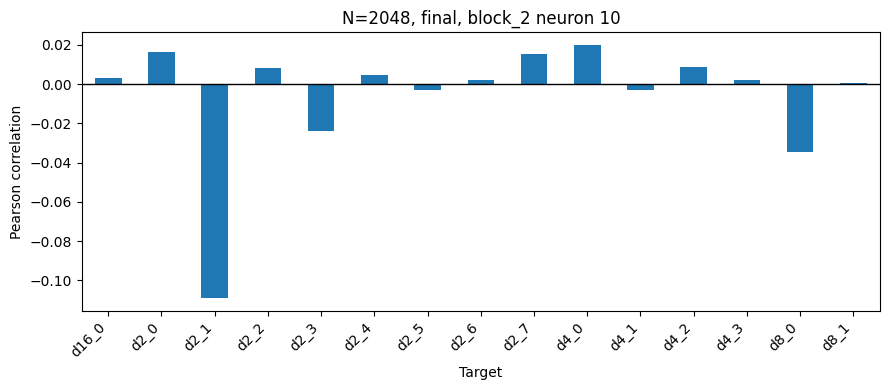

In [28]:
import matplotlib.pyplot as plt

SELECT_LAYER_IDX = 2
SELECT_NEURON_IDX = 10

if SELECT_LAYER_IDX not in correlation_by_layer:
    raise ValueError(f"SELECT_LAYER_IDX must be one of {list(correlation_by_layer)}")
selected_corr = correlation_by_layer[SELECT_LAYER_IDX]
if SELECT_NEURON_IDX < 0 or SELECT_NEURON_IDX >= selected_corr.shape[0]:
    raise ValueError(f"SELECT_NEURON_IDX must be in [0, {selected_corr.shape[0] - 1}]")

selected_neuron_correlations = pd.DataFrame(
    {
        "target": target_columns,
        "correlation": selected_corr[SELECT_NEURON_IDX].numpy(),
    }
)
selected_neuron_correlations["abs_correlation"] = selected_neuron_correlations["correlation"].abs()
selected_neuron_correlations = selected_neuron_correlations.sort_values(
    "abs_correlation",
    ascending=False,
)

layer_name = "embedding" if SELECT_LAYER_IDX == 0 else f"block_{SELECT_LAYER_IDX}"
print(f"Correlations for N={CORRELATION_N}, {correlation_checkpoint_label}, {layer_name}, neuron {SELECT_NEURON_IDX}")
display(selected_neuron_correlations)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(9, 4))
selected_neuron_correlations.sort_values("target").plot(
    x="target",
    y="correlation",
    kind="bar",
    legend=False,
    ax=ax,
)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_xlabel("Target")
ax.set_ylabel("Pearson correlation")
ax.set_title(
    f"N={CORRELATION_N}, {correlation_checkpoint_label}, {layer_name} neuron {SELECT_NEURON_IDX}"
)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plot_path = (
    PLOTS_DIR
    / f"neuron_target_correlations_N_{CORRELATION_N}_{correlation_checkpoint_label}_layer_{SELECT_LAYER_IDX}_neuron_{SELECT_NEURON_IDX}.png"
)
fig.savefig(plot_path, dpi=150)
print(f"Saved plot to {plot_path}")
plt.show()
